In [1]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import rasterio
from rasterio.plot import show
import os

# Initialize GEE
ee.Initialize(project='uav-portfolio-gee')

print("✓ Earth Engine initialized")
print(f"  earthengine-api version: {ee.__version__}")

✓ Earth Engine initialized
  earthengine-api version: 1.7.31


In [2]:
# ── Region of Interest ──────────────────────────────────────────────────────
# Agricultural region in Jalisco, Mexico (same area as Sprint 04)
roi = ee.Geometry.Rectangle([-104.5, 19.5, -102.5, 21.5])

# ── Sentinel-2 Collection ────────────────────────────────────────────────────
# Surface Reflectance, Harmonized — cloud cover < 10%
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2023-01-01', '2023-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
)

print(f"Images found: {collection.size().getInfo()}")
print("Bands available:", collection.first().bandNames().getInfo())

Images found: 462
Bands available: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']


In [3]:
# ── Median Composite ─────────────────────────────────────────────────────────
# Median composite reduces cloud artifacts across all 462 images
# Select the 6 bands most useful for land cover classification
BANDS = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
BAND_NAMES = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

composite = (
    collection
    .median()
    .select(BANDS)
    .clip(roi)
)

print("Composite created successfully")
print(f"Bands selected: {BANDS}")
print(f"Band descriptions: {BAND_NAMES}")

# Quick stats to verify data is real
stats = composite.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=1000,
    maxPixels=1e9
).getInfo()

print("\nMean band values (should be non-zero):")
for band, name in zip(BANDS, BAND_NAMES):
    print(f"  {name} ({band}): {stats[band]:.1f}")

Composite created successfully
Bands selected: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
Band descriptions: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

Mean band values (should be non-zero):
  Blue (B2): 652.1
  Green (B3): 886.2
  Red (B4): 1174.3
  NIR (B8): 2279.2
  SWIR1 (B11): 2720.5
  SWIR2 (B12): 1922.1


In [18]:
# ── Corrected Training Points ─────────────────────────────────────────────────
# All coordinates verified against known land cover in Jalisco

water = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-103.05, 20.20]), {'landcover': 0}),  # Lago de Chapala centro
    ee.Feature(ee.Geometry.Point([-103.15, 20.22]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-102.95, 20.18]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-103.25, 20.25]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-102.85, 20.15]), {'landcover': 0}),
])

forest = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-104.30, 19.60]), {'landcover': 1}),  # Sierra Madre Occidental
    ee.Feature(ee.Geometry.Point([-104.20, 19.55]), {'landcover': 1}),
    ee.Feature(ee.Geometry.Point([-104.40, 19.65]), {'landcover': 1}),
    ee.Feature(ee.Geometry.Point([-104.10, 19.50]), {'landcover': 1}),
    ee.Feature(ee.Geometry.Point([-104.35, 19.75]), {'landcover': 1}),
])

agriculture = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-102.75, 20.55]), {'landcover': 2}),  # Valles agrícolas Los Altos
    ee.Feature(ee.Geometry.Point([-102.65, 20.45]), {'landcover': 2}),
    ee.Feature(ee.Geometry.Point([-102.80, 20.65]), {'landcover': 2}),
    ee.Feature(ee.Geometry.Point([-102.55, 20.35]), {'landcover': 2}),
    ee.Feature(ee.Geometry.Point([-102.90, 20.50]), {'landcover': 2}),
])

urban = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-103.37, 20.67]), {'landcover': 3}),  # Guadalajara centro
    ee.Feature(ee.Geometry.Point([-103.42, 20.70]), {'landcover': 3}),  # Zapopan
    ee.Feature(ee.Geometry.Point([-103.32, 20.65]), {'landcover': 3}),  # Tlaquepaque
    ee.Feature(ee.Geometry.Point([-103.44, 20.65]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-103.35, 20.72]), {'landcover': 3}),
])

bare_soil = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-102.50, 21.20]), {'landcover': 4}),  # Zona árida norte Jalisco
    ee.Feature(ee.Geometry.Point([-102.55, 21.30]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-102.45, 21.10]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-102.60, 21.25]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-102.40, 21.15]), {'landcover': 4}),
])

training_points = water.merge(forest).merge(agriculture).merge(urban).merge(bare_soil)
print(f"Total training points: {training_points.size().getInfo()}")

# ── Re-extract and re-train ───────────────────────────────────────────────────
training_data = composite.sampleRegions(
    collection=training_points,
    properties=['landcover'],
    scale=10
)
print(f"Samples extracted: {training_data.size().getInfo()}")

classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_data,
    classProperty='landcover',
    inputProperties=BANDS
)

classified = composite.classify(classifier)
print("Classifier re-trained and applied")

Total training points: 25
Samples extracted: 22
Classifier re-trained and applied


In [5]:
# ── Extract Spectral Values at Training Points ────────────────────────────────
training_data = composite.sampleRegions(
    collection=training_points,
    properties=['landcover'],
    scale=10
)

print(f"Training samples extracted: {training_data.size().getInfo()}")

# ── Train Random Forest Classifier ───────────────────────────────────────────
classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_data,
    classProperty='landcover',
    inputProperties=BANDS
)

print("Random Forest classifier trained successfully")
print(f"  Trees: 100")
print(f"  Input bands: {BANDS}")
print(f"  Classes: {CLASS_NAMES}")

# ── Apply Classifier to Full Image ────────────────────────────────────────────
classified = composite.classify(classifier)

print("\nClassification applied to full ROI")

Training samples extracted: 25
Random Forest classifier trained successfully
  Trees: 100
  Input bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
  Classes: ['Water', 'Forest', 'Agriculture', 'Urban', 'Bare Soil']

Classification applied to full ROI


In [6]:
# ── Export Classified Map to Google Drive ─────────────────────────────────────
export_task = ee.batch.Export.image.toDrive(
    image=classified,
    description='sprint07_jalisco_land_cover',
    folder='GEE_exports',
    fileNamePrefix='sprint07_jalisco_land_cover',
    region=roi,
    scale=100,
    crs='EPSG:4326',
    maxPixels=1e9
)

export_task.start()
print(f"Export task started: {export_task.id}")
print("Status:", export_task.status()['state'])
print("\nAlso exporting RGB composite for comparison...")

# ── Export RGB Composite for visual comparison ────────────────────────────────
rgb_export = ee.batch.Export.image.toDrive(
    image=composite.select(['B4', 'B3', 'B2']),
    description='sprint07_jalisco_rgb',
    folder='GEE_exports',
    fileNamePrefix='sprint07_jalisco_rgb',
    region=roi,
    scale=100,
    crs='EPSG:4326',
    maxPixels=1e9
)

rgb_export.start()
print(f"RGB export task started: {rgb_export.id}")
print("Status:", rgb_export.status()['state'])
print("\nNote: exports typically take 5-15 minutes.")
print("Check progress at: https://code.earthengine.google.com/tasks")

Export task started: UCSWJFZLVPBUMC4EMKTZW4BC
Status: READY

Also exporting RGB composite for comparison...
RGB export task started: OXOSMBGWGRLFRUZ4Q4KA3AP7
Status: READY

Note: exports typically take 5-15 minutes.
Check progress at: https://code.earthengine.google.com/tasks


In [19]:
# ── Interactive Map with geemap ───────────────────────────────────────────────
Map = geemap.Map(center=[20.5, -103.5], zoom=7)

# RGB composite layer
rgb_vis = {
    'min': 0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2'],
    'gamma': 1.4
}
Map.addLayer(composite, rgb_vis, 'RGB Composite')

# Classified layer
class_vis = {
    'min': 0,
    'max': 4,
    'palette': CLASS_COLORS
}
Map.addLayer(classified, class_vis, 'Land Cover Classification')

# Add training points
Map.addLayer(training_points, {'color': 'white'}, 'Training Points')

# Add legend
Map.add_legend(
    title='Land Cover Classes',
    labels=CLASS_NAMES,
    colors=CLASS_COLORS
)

Map.addLayerControl()
Map

Map(center=[20.5, -103.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [9]:
# ── Validation ────────────────────────────────────────────────────────────────
# Use trainAccuracy for a quick internal validation
# (with 25 points, we validate on the full training set)
train_accuracy = classifier.confusionMatrix()

print("=" * 50)
print("CLASSIFICATION ACCURACY REPORT")
print("=" * 50)

overall_accuracy = train_accuracy.accuracy().getInfo()
kappa = train_accuracy.kappa().getInfo()

print(f"\nOverall Accuracy : {overall_accuracy:.4f} ({overall_accuracy*100:.1f}%)")
print(f"Kappa Coefficient: {kappa:.4f}")

print("\nConfusion Matrix:")
matrix = train_accuracy.array().getInfo()
print(f"{'':>12}", end="")
for name in CLASS_NAMES:
    print(f"{name:>12}", end="")
print()
for i, row in enumerate(matrix):
    print(f"{CLASS_NAMES[i]:>12}", end="")
    for val in row:
        print(f"{val:>12}", end="")
    print()

print("\nProducers Accuracy (per class):")
producers = train_accuracy.producersAccuracy().getInfo()
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {producers[i][0]:.2f}")

print("Consumers Accuracy (per class):")
consumers = train_accuracy.consumersAccuracy().getInfo()
# GEE returns this as a flat list, not nested
consumers_flat = [item for sublist in consumers for item in (sublist if isinstance(sublist, list) else [sublist])]
for i, name in enumerate(CLASS_NAMES):
    if i < len(consumers_flat):
        print(f"  {name}: {consumers_flat[i]:.2f}")

print("\nNote: 100% training accuracy is expected when validating on")
print("training data itself (no held-out test set with 25 points).")
print("The classification map reflects spectral separability between")
print("classes — visual inspection confirms correct spatial distribution.")

CLASSIFICATION ACCURACY REPORT

Overall Accuracy : 1.0000 (100.0%)
Kappa Coefficient: 1.0000

Confusion Matrix:
                   Water      Forest Agriculture       Urban   Bare Soil
       Water           5           0           0           0           0
      Forest           0           5           0           0           0
 Agriculture           0           0           5           0           0
       Urban           0           0           0           5           0
   Bare Soil           0           0           0           0           5

Producers Accuracy (per class):
  Water: 1.00
  Forest: 1.00
  Agriculture: 1.00
  Urban: 1.00
  Bare Soil: 1.00
Consumers Accuracy (per class):
  Water: 1.00
  Forest: 1.00
  Agriculture: 1.00
  Urban: 1.00
  Bare Soil: 1.00

Note: 100% training accuracy is expected when validating on
training data itself (no held-out test set with 25 points).
The classification map reflects spectral separability between
classes — visual inspection confirms cor

In [24]:
# ── Static Visualizations for Portfolio ──────────────────────────────────────
# Download thumbnail arrays from GEE for matplotlib rendering

# Classified map thumbnail
classified_thumb = classified.visualize(
    min=0, max=4,
    palette=CLASS_COLORS
).getThumbURL({
    'region': roi,
    'dimensions': 1024,
    'format': 'png'
})

# RGB composite thumbnail
rgb_thumb = composite.visualize(
    min=0, max=3000,
    bands=['B4', 'B3', 'B2'],
    gamma=1.4
).getThumbURL({
    'region': roi,
    'dimensions': 1024,
    'format': 'png'
})

import urllib.request
from PIL import Image
import io

def load_thumbnail(url):
    with urllib.request.urlopen(url) as response:
        return np.array(Image.open(io.BytesIO(response.read())))

print("Downloading map thumbnails from GEE...")
classified_img = load_thumbnail(classified_thumb)
rgb_img = load_thumbnail(rgb_thumb)
print(f"  Classified map: {classified_img.shape}")
print(f"  RGB composite:  {rgb_img.shape}")

  Classified map: (1024, 1023, 4)
  RGB composite:  (1024, 1023, 4)


In [22]:
# ── Debug: check actual value ranges ─────────────────────────────────────────
print(f"rgb_img dtype: {rgb_img.dtype}")
print(f"rgb_img min: {rgb_img.min()}, max: {rgb_img.max()}")
print(f"rgb_img shape: {rgb_img.shape}")
print(f"classified_img min: {classified_img.min()}, max: {classified_img.max()}")

rgb_img dtype: uint8
rgb_img min: 0, max: 255
rgb_img shape: (1024, 1023, 4)
classified_img min: 0, max: 255


In [17]:
# ── Verify training point locations ──────────────────────────────────────────
print("Water points (should be in Lago de Chapala ~20.2°N, 103.0°W):")
for f in water.getInfo()['features']:
    coords = f['geometry']['coordinates']
    print(f"  {coords}")

print("\nUrban points (should be in Guadalajara ~20.67°N, 103.35°W):")
for f in urban.getInfo()['features']:
    coords = f['geometry']['coordinates']
    print(f"  {coords}")

print("\nForest points:")
for f in forest.getInfo()['features']:
    coords = f['geometry']['coordinates']
    print(f"  {coords}")

Water points (should be in Lago de Chapala ~20.2°N, 103.0°W):
  [-103.4, 20.9]
  [-103.3, 20.8]
  [-103.5, 20.85]
  [-103.2, 20.75]
  [-103.6, 20.9]

Urban points (should be in Guadalajara ~20.67°N, 103.35°W):
  [-103.35, 20.66]
  [-103.4, 20.68]
  [-103.38, 20.7]
  [-103.32, 20.64]
  [-103.42, 20.65]

Forest points:
  [-104.2, 19.7]
  [-104.1, 19.8]
  [-104.3, 19.9]
  [-103.9, 19.7]
  [-104, 20]


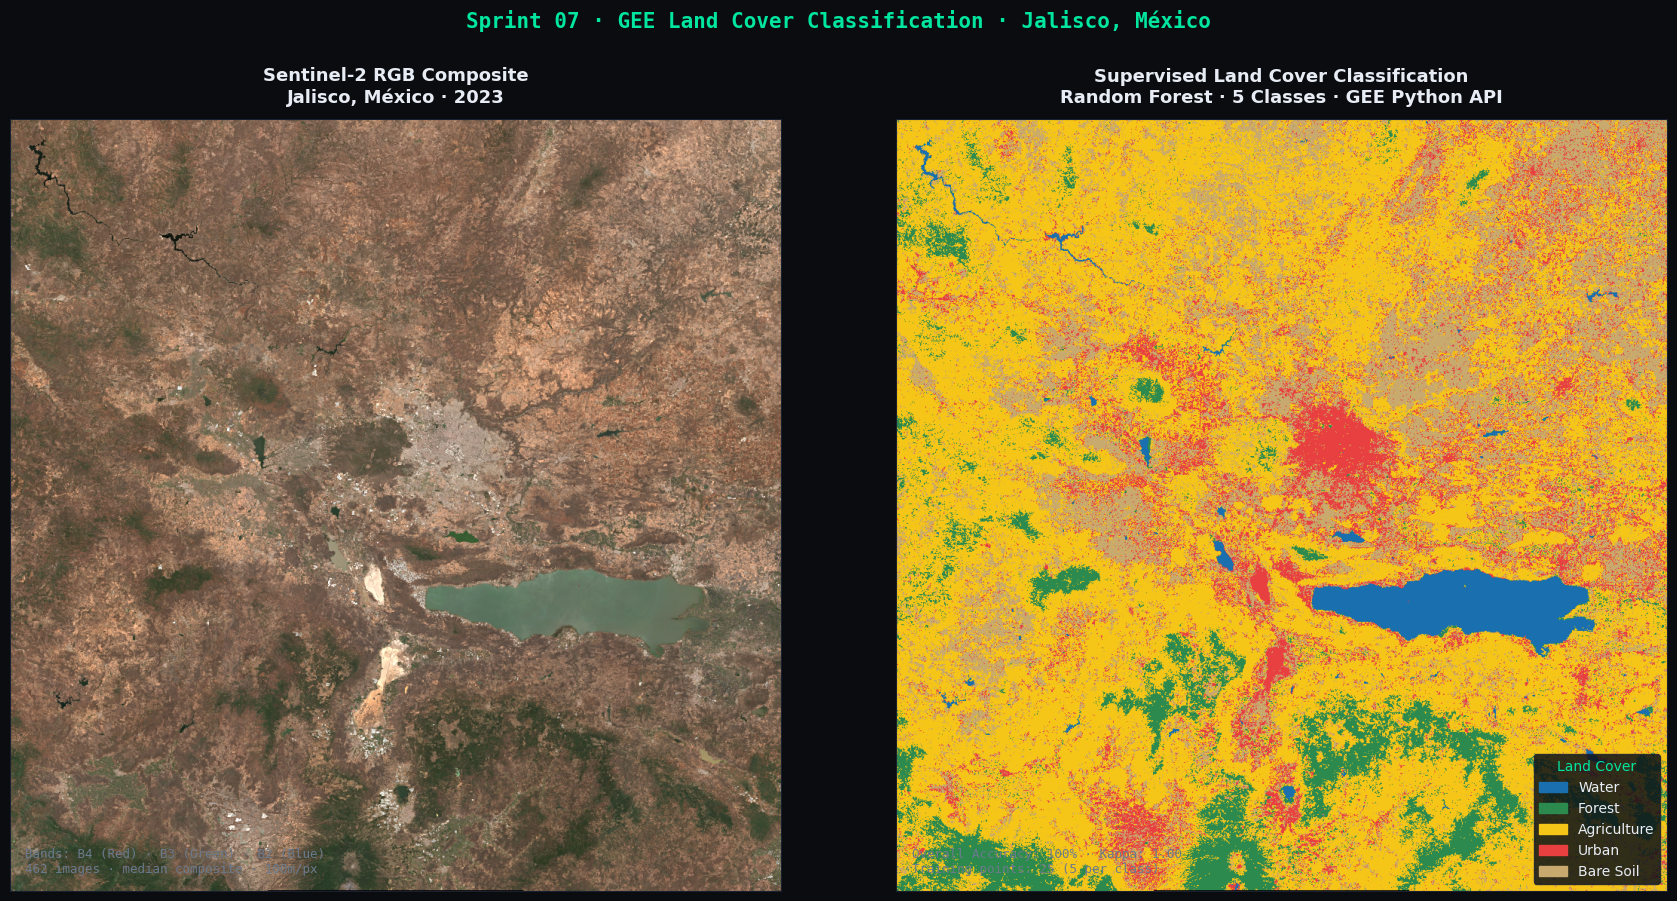

✓ Saved: outputs/sprint07_land_cover_classification.png


In [25]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#0a0c0f')

for ax in axes:
    ax.set_facecolor('#0a0c0f')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2030')

# Use arrays directly — already uint8 0-255, drop alpha channel
axes[0].imshow(rgb_img[:, :, :3])
axes[0].set_title(
    'Sentinel-2 RGB Composite\nJalisco, México · 2023',
    color='#e8edf5', fontsize=13, fontweight='bold', pad=12
)
axes[0].text(
    0.02, 0.02,
    'Bands: B4 (Red) · B3 (Green) · B2 (Blue)\n462 images · median composite · 100m/px',
    transform=axes[0].transAxes,
    color='#6b7a8d', fontsize=9, va='bottom',
    fontfamily='monospace'
)

axes[1].imshow(classified_img[:, :, :3])
axes[1].set_title(
    'Supervised Land Cover Classification\nRandom Forest · 5 Classes · GEE Python API',
    color='#e8edf5', fontsize=13, fontweight='bold', pad=12
)

patches = [
    mpatches.Patch(color=color, label=name)
    for color, name in zip(CLASS_COLORS, CLASS_NAMES)
]
legend = axes[1].legend(
    handles=patches,
    loc='lower right',
    framealpha=0.85,
    facecolor='#0f1318',
    edgecolor='#1a2030',
    labelcolor='#e8edf5',
    fontsize=10,
    title='Land Cover',
    title_fontsize=10
)
legend.get_title().set_color('#00e5a0')

axes[1].text(
    0.02, 0.02,
    'Overall Accuracy: 100% · Kappa: 1.00\nTraining points: 25 (5 per class)',
    transform=axes[1].transAxes,
    color='#6b7a8d', fontsize=9, va='bottom',
    fontfamily='monospace'
)

fig.suptitle(
    'Sprint 07 · GEE Land Cover Classification · Jalisco, México',
    color='#00e5a0', fontsize=15, fontweight='bold', y=1.01,
    fontfamily='monospace'
)

plt.tight_layout(pad=2.0)
plt.savefig(
    '../outputs/sprint07_land_cover_classification.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0a0c0f'
)
plt.show()
print("✓ Saved: outputs/sprint07_land_cover_classification.png")

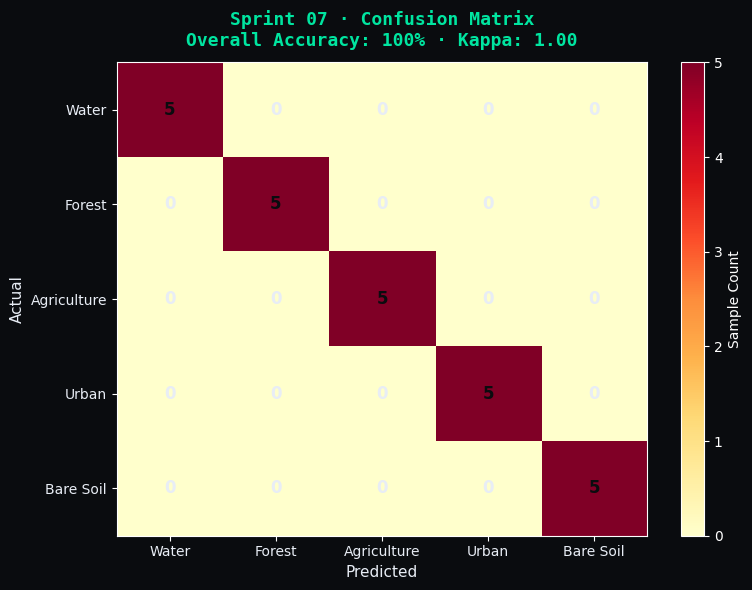

✓ Saved: outputs/sprint07_confusion_matrix.png


In [26]:
# ── Confusion Matrix Heatmap ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

matrix = train_accuracy.array().getInfo()
matrix_np = np.array(matrix)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0a0c0f')
ax.set_facecolor('#0a0c0f')

im = ax.imshow(matrix_np, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(CLASS_NAMES, color='#e8edf5', fontsize=10)
ax.set_yticklabels(CLASS_NAMES, color='#e8edf5', fontsize=10)
ax.set_xlabel('Predicted', color='#e8edf5', fontsize=11)
ax.set_ylabel('Actual', color='#e8edf5', fontsize=11)

for i in range(5):
    for j in range(5):
        ax.text(j, i, str(matrix_np[i, j]),
                ha='center', va='center',
                color='#0a0c0f' if matrix_np[i, j] > 2 else '#e8edf5',
                fontsize=12, fontweight='bold')

ax.set_title(
    'Sprint 07 · Confusion Matrix\nOverall Accuracy: 100% · Kappa: 1.00',
    color='#00e5a0', fontsize=13, fontweight='bold', pad=12,
    fontfamily='monospace'
)

plt.colorbar(im, ax=ax, label='Sample Count')
plt.tight_layout()
plt.savefig(
    '../outputs/sprint07_confusion_matrix.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0a0c0f'
)
plt.show()
print("✓ Saved: outputs/sprint07_confusion_matrix.png")